## Playlist Generation — End-to-End

This notebook connects the two halves of the project:

**Part A — Airbnb NLP** (mirrors `Airbnb/airbnb-preprocessing.ipynb` + `Airbnb/airbnb-nlp.ipynb`)
- Load a city CSV
- Select relevant columns
- Clean text, tokenize, remove stopwords, lemmatize
- Extract TF-IDF keywords per listing → `df['keywords']`

**Part B — Spotify Recommendation** (uses `recommendation/keyword_embedder.py` + `recommendation/recommender.py`)
- Load the clustered Spotify dataset
- Pick a listing, inspect its keywords
- Run the 4-layer recommender → ranked playlist

---
| Recommender Layer | Signal | Method |
|---|---|---|
| 1 | **Lyrics match** | Location/place terms searched in song lyrics |
| 2 | **Emotion match** | Keywords embedded → cosine sim to emotion anchors |
| 3 | **Audio cosine** | Keywords → target audio vector → cosine sim per track |
| 4 | **Cluster boost** | Closest K-means centroid to target vector gets a multiplier |

---
## Part A: Airbnb NLP Pipeline

Replicates the logic from `airbnb-preprocessing.ipynb` and `airbnb-nlp.ipynb` on a single city CSV.

In [7]:
import sys
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk import bigrams
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Imports OK")

Imports OK


### A0. Direct Airbnb NLP call
We can bypass the step-by-step Part A preprocessing by invoking the consolidated helper
`Airbnb.nlp_pipeline.analyze_listing_from_url`. This function looks up a listing in the
prepared dataset, extracts TF-IDF vibe keywords, and scores NRC emotions in one shot.
Run the cell below to fetch metadata for any Airbnb URL present in `Airbnb/data/Output.csv`
without re-running the legacy cells that follow.

In [23]:
# Same columns as airbnb-preprocessing.ipynb
columns_to_keep = [
    "id",
    "listing_url",
    "name",
    "description",
    "neighborhood_overview",
    "neighbourhood_cleansed",
    "property_type",
    "room_type",
    "accommodates",
    "amenities",
]

CITY_CSV = "../Airbnb/Airbnb City Extracts/test-city-1.csv"

raw_df = pd.read_csv(CITY_CSV, low_memory=False)
df = raw_df[[col for col in columns_to_keep if col in raw_df.columns]].copy()

print(f"Loaded {len(df):,} listings")
df.head(3)

Loaded 600 listings


,id,listing_url,name,description,neighborhood_overview,neighbourhood_cleansed,property_type,room_type,accommodates,amenities
0,1913774,https://www.airbnb.com/rooms/1913774,Downtown Bozeman Vacation Rental,Just four easy blocks from historic downtown B...,NaN,Bozeman,Entire guesthouse,Entire home/apt,2,"[""Shower gel"", ""Essentials"", ""Hair dryer"", ""Ex..."
1,1950545,https://www.airbnb.com/rooms/1950545,Northside Hideaway,"Free, fast Wi-Fi for remote learning/working n...",NaN,Bozeman,Entire home,Entire home/apt,4,"[""Essentials"", ""Fire extinguisher"", ""Hair drye..."
2,2390321,https://www.airbnb.com/rooms/2390321,2 Blocks 2 Main,This space is designed for 1-2 people that wan...,I love that it is 2 blocks from the heart of d...,Bozeman,Entire rental unit,Entire home/apt,2,"[""Essentials"", ""Fire extinguisher"", ""Hair drye..."


In [42]:
from Airbnb.nlp_pipeline import (
    analyze_listing_from_url,
    load_listing_dataset,
    load_nrc_lexicon,
)

DATASET_PATH = os.path.abspath("../Airbnb/data/Output.csv")
NRC_PATH = os.path.abspath("../Airbnb/emolex/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt")

all_listings = load_listing_dataset(DATASET_PATH)
nrc_lookup = load_nrc_lexicon(NRC_PATH)


def analyze_listing_from_row(row):
    keyword_json, emotion_json = analyze_listing_from_url(
        url=row["listing_url"],
        dataset_path=DATASET_PATH,
        nrc_path=NRC_PATH,
    )

    return pd.Series(
        {
            "keywords": keyword_json.get("keywords", []),
            "dominant_emotion": emotion_json.get("dominant_emotion"),
            "emotion_scores": emotion_json.get("emotion_scores", {}),
        }
    )

analysis = df.apply(analyze_listing_from_row, axis=1)
for col in analysis.columns:
    df[col] = analysis[col]

print(df[["keywords", "dominant_emotion", "emotion_scores"]].head(30))

                                             keywords dominant_emotion  \
0          [easy block, loft retreat, modern amenity]     anticipation   
1                                      [keyless self]             None   
2                                                  []            trust   
3           [south side, sunny porch, equipped basic]     anticipation   
4       [downtown yard, top historic, lindley street]     anticipation   
5                    [open motherinlaw, much explore]     anticipation   
6                       [minimum rental, main street]              joy   
7   [full showertub, narrow twin, full washerdryer...     anticipation   
8   [yellow dog, skiing bridger, big sky, historic...     anticipation   
9   [montana furniture, open floor, close shopping...            trust   
10  [showerbaths toilet, outdoor fireplace, availa...          disgust   
11  [new furnishing, open floor, additional bedroo...     anticipation   
12  [comfortable townhouse, downtown m

---
## Part B: Spotify Recommendation Pipeline

Takes `df['keywords']` from Part A and generates a playlist for a chosen listing.

### B1. Load the clustered Spotify dataset

Rebuilds `clustered_df` and `scaled_df` using the same steps as `spotify/spotify_clustering.ipynb` with `k=5`.

In [43]:
SPOTIFY_DIR = os.path.abspath("../spotify")
CLUSTERING_DIR = os.path.abspath("../spotify-clustering")
RECO_DIR = os.path.abspath(".")
for p in [SPOTIFY_DIR, CLUSTERING_DIR, RECO_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

In [44]:
# Add spotify/ and recommendation/ to path for imports
SPOTIFY_DIR = os.path.abspath("../spotify-clustering")
RECO_DIR    = os.path.abspath(".")
for p in [SPOTIFY_DIR, RECO_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

from data_loader import (
    AUDIO_FEATURE_COLS,
    load_spotify,
    select_features,
    remove_outliers,
    scale_features,
)
from clustering import fit_kmeans

import importlib
import keyword_embedder
importlib.reload(keyword_embedder)
from keyword_embedder import resolve_keywords, explain_resolution, build_lyric_index

from recommender import recommend

print("Spotify imports OK")

Spotify imports OK


In [45]:
SPOTIFY_PATH = "../spotify-clustering/dataset/spotify_dataset_lyrics.csv"

df_spotify = load_spotify(SPOTIFY_PATH)
filtered_df, feature_df = select_features(df_spotify, AUDIO_FEATURE_COLS)
filtered_df, feature_df = remove_outliers(filtered_df, feature_df, AUDIO_FEATURE_COLS)
scaled_df, scaler       = scale_features(feature_df, AUDIO_FEATURE_COLS)

K_FINAL = 5
kmeans, clusters = fit_kmeans(scaled_df, k=K_FINAL)

clustered_df = filtered_df.copy()
clustered_df["cluster"] = clusters

print(f"clustered_df: {clustered_df.shape[0]:,} tracks, {clustered_df.shape[1]} columns")
clustered_df[["track_name", "artist", "genre", "emotion", "cluster"]].head()

Loaded 551443 rows, 21 columns from ../spotify-clustering/dataset/spotify_dataset_lyrics.csv
Using 551443 tracks with complete audio features
Flagged 21665 tracks (>±4.0 z-score on any feature)
Retained 529778 tracks after trimming outliers
clustered_df: 529,778 tracks, 22 columns


,track_name,artist,genre,emotion,cluster
0,Even When the Waters Cold,!!!,hip hop,sadness,2
1,One Girl / One Boy,!!!,hip hop,sadness,2
2,Pardon My Freedom,!!!,hip hop,joy,4
3,Ooo,!!!,hip hop,joy,2
4,Freedom 15,!!!,hip hop,joy,2


In [17]:
# Build the lyric index for retrieve-then-aggregate audio targeting.
# This embeds all 529k track lyrics once and caches them in memory.
# Takes ~2-3 minutes on first run; subsequent calls in the same session are instant.
build_lyric_index(clustered_df, scaled_df, AUDIO_FEATURE_COLS)

Building lyric index for 529,778 tracks (2070 batches) …


Embedding lyrics:   0%|          | 0/2070 [00:00<?, ?batch/s]

Lyric index ready.


In [37]:
LISTING_IDX = 8  # change to try a different listing

listing = df.iloc[LISTING_IDX]

print(f"Listing ID   : {listing['id']}")
print(f"Name         : {listing['name']}")
print(f"Neighborhood : {listing.get('neighbourhood_cleansed', 'N/A')}")
print(f"Property type: {listing.get('property_type', 'N/A')}")
print(f"Room type    : {listing.get('room_type', 'N/A')}")
print()
print("Original description:")
print(listing['description'])
print()
print("Extracted keywords:", listing['keywords'])

Listing ID   : 4134363
Name         : Yellow Dogs Cottage: Unique Large Downtown Cottage
Neighborhood : Bozeman
Property type: Entire place
Room type    : Entire home/apt

Original description:
Yellow Dogs Cottage is a Stylish and uniquely charming cottage is walking distance to Montana State University and town, close to skiing at Bridger Bowl & Big Sky, fishing, hiking, and so much more. Nestled in a lush, historic South-side neighborhood this cottage is thoughtfully and lovingly renovated and decorated. The cottage is always cleaned & sanitized between guests. One space flows into the next, making this a relaxing get-away spot.

Extracted keywords: ['yellow dog', 'skiing bridger', 'big sky', 'historic southside']


### B3. Inspect keyword resolution

Shows how the embedding model interprets the listing's keywords — which emotions it infers, what audio target vector it derives, and which terms are routed to the lyrics-search layer.

In [46]:
explain_resolution(df['keywords'][8])

=== Keyword Embedding Resolution ===
Input keywords   : ['yellow dog', 'skiing bridger', 'big sky', 'historic southside']
Location terms   : []  ← searched in lyrics

Emotion weights (zero-shot NLI):
  joy          0.420  ████████████████
  surprise     0.407  ████████████████
  neutral      0.089  ███
  fear         0.037  █
  anger        0.030  █
  sadness      0.017  

Audio target vector [FALLBACK (index not built)]:


### B4. Generate the playlist

In [47]:
playlist = recommend(
    keywords=listing['keywords'],
    df=clustered_df,
    scaled_df=scaled_df,
    top_n=20,
)

display_cols = [
    "track_name", "artist", "genre", "emotion", "cluster",
    "score", "score_lyrics", "score_emotion", "score_audio", "score_cluster",
]
playlist[display_cols]

,track_name,artist,genre,emotion,cluster,score,score_lyrics,score_emotion,score_audio,score_cluster
0,Good Mourning,"The Kid LAROI,mgk",hip hop,joy,2,0.525,0.0,1.0,0.5,1.0
1,Buzzin,"Blake Shelton,RaeLynn",hip hop,joy,2,0.525,0.0,1.0,0.5,1.0
2,TACONAFIDE - Tamagotchi English Translation,Soasoa-Nui,hip hop,joy,2,0.525,0.0,1.0,0.5,1.0
3,Lifes a Bitch,Radiant Children,"soundtrack,classical,ambient",joy,2,0.525,0.0,1.0,0.5,1.0
4,Traffic,Curren$y,"rap,hip hop",joy,2,0.525,0.0,1.0,0.5,1.0
5,Name for You,The Shins,"indie rock,folk,pop",joy,2,0.525,0.0,1.0,0.5,1.0
6,Rare,Radiant Children,"soundtrack,classical,ambient",joy,2,0.525,0.0,1.0,0.5,1.0
7,Live from the Bubble,L.A.B.,"reggae,funk,blues",joy,2,0.525,0.0,1.0,0.5,1.0
8,If I Go,Blakey,jazz,joy,2,0.525,0.0,1.0,0.5,1.0
9,Johnny B. Goode,Elvis Presley,"blues,gospel,pop rock",joy,2,0.525,0.0,1.0,0.5,1.0


### B5. Score breakdown — what drove each recommendation

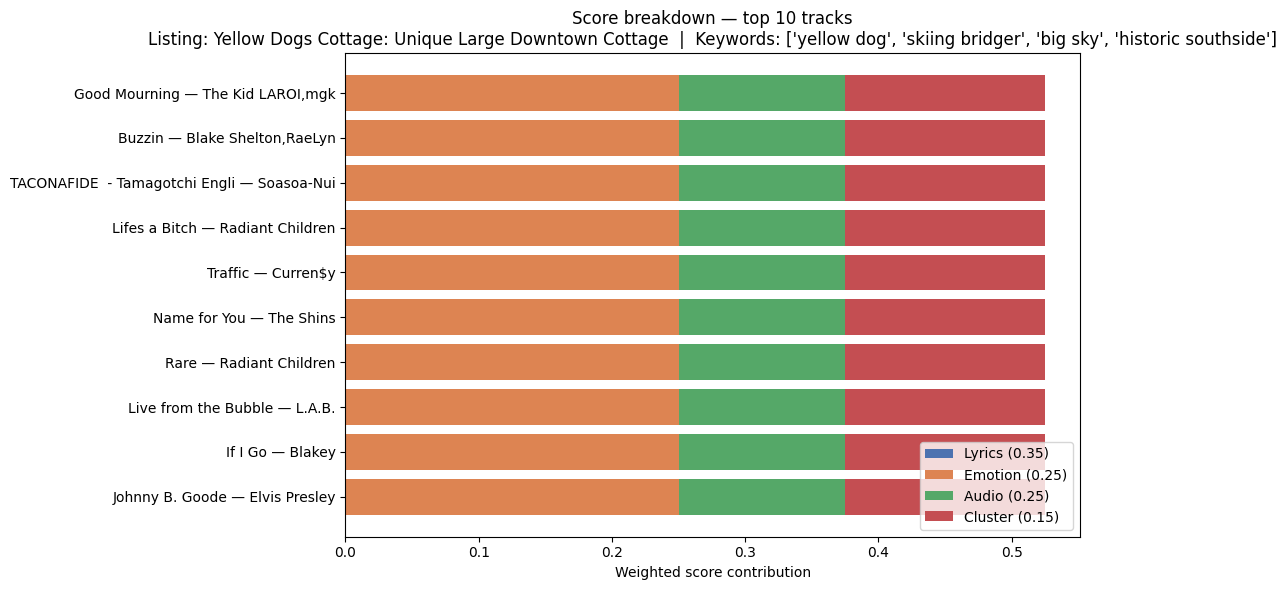

In [49]:
top10 = playlist.head(10).copy()
top10["label"] = top10["track_name"].str[:30] + " — " + top10["artist"].str[:20]

fig, ax = plt.subplots(figsize=(11, 6))
layers  = ["score_lyrics", "score_emotion", "score_audio", "score_cluster"]
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
labels  = ["Lyrics (0.35)", "Emotion (0.25)", "Audio (0.25)", "Cluster (0.15)"]
weights = [0.35, 0.25, 0.25, 0.15]

bottoms = np.zeros(len(top10))
for layer, color, label, w in zip(layers, colors, labels, weights):
    vals = top10[layer].values * w
    ax.barh(top10["label"], vals, left=bottoms, color=color, label=label)
    bottoms += vals

ax.set_xlabel("Weighted score contribution")
ax.set_title(
    f"Score breakdown — top 10 tracks\n"
    f"Listing: {listing['name']}  |  Keywords: {listing['keywords']}"
)
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### B6. Browse multiple listings at once

Generate playlists for the first `N` listings and compare their top track.

In [53]:
N = 20  # number of listings to sample

rows = []
for _, row in df.head(N).iterrows():
    listing_keywords = row.get("keywords") or []
    if isinstance(listing_keywords, pd.Series):
        listing_keywords = listing_keywords.tolist()
    elif isinstance(listing_keywords, str):
        listing_keywords = [listing_keywords]

    pl = recommend(
        keywords=listing_keywords,
        df=clustered_df,
        scaled_df=scaled_df,
        top_n=1,
    )
    top = pl.iloc[0]
    rows.append({
        "listing_name" : row["name"],
        "keywords"     : listing_keywords,
        "top_track"    : top["track_name"],
        "artist"       : top["artist"],
        "emotion"      : top["emotion"],
        "genre"        : top["genre"],
        "score"        : round(top["score"], 4),
    })

pd.DataFrame(rows)

,listing_name,keywords,top_track,artist,emotion,genre,score
0,Downtown Bozeman Vacation Rental,"[easy block, loft retreat, modern amenity]",Good Mourning,"The Kid LAROI,mgk",joy,hip hop,0.525
1,Northside Hideaway,[keyless self],Plutos Last Comet,Tory Lanez,surprise,"hip hop,dancehall",0.400
2,2 Blocks 2 Main,[],Even When the Waters Cold,!!!,sadness,hip hop,0.275
3,Modern Home Near Campus & Downtown,"[south side, sunny porch, equipped basic]",Ever South,Drive-By Truckers,joy,hip hop,0.400
4,"Charming downtown home, Bogart park","[downtown yard, top historic, lindley street]",Good Mourning,"The Kid LAROI,mgk",joy,hip hop,0.525
5,Sunny Bozeman MSU Cottage,"[open motherinlaw, much explore]",Brass Goggles,Steam Powered Giraffe,surprise,rock,0.525
6,Lovely 2BR Bozeman Cottage near Main St,"[minimum rental, main street]",Plutos Last Comet,Tory Lanez,surprise,"hip hop,dancehall",0.400
7,"The Loft: near MSU, private entry, kitchen & b...","[full showertub, narrow twin, full washerdryer...",Brass Goggles,Steam Powered Giraffe,surprise,rock,0.525
8,Yellow Dogs Cottage: Unique Large Downtown Cot...,"[yellow dog, skiing bridger, big sky, historic...",Good Mourning,"The Kid LAROI,mgk",joy,hip hop,0.525
9,Executive 6 Month Rental with Hot Tub,"[montana furniture, open floor, close shopping...",Slow Motion Tha Rotation Song,"Hori Shaw,Classick J",surprise,hip hop,0.525
